In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import torchvision.transforms.functional as F

# 1. Setup Device (M2 Chip Support)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

class SquarePad:
    def __call__(self, image):
        w, h = image.size
        max_wh = max(w, h)
        hp = (max_wh - w) // 2
        vp = (max_wh - h) // 2
        padding = (hp, vp, max_wh - w - hp, max_wh - h - vp)
        return F.pad(image, padding, (200,200,200), 'constant')

# 2. Online Augmentation Pipeline
data_transforms = transforms.Compose([
    SquarePad(), # First, make it a square with padding
    transforms.Resize((224, 224)), # Standard size for pre-trained models
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15, fill=(200,200,200)),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2), # Handles lighting variance
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Standard ImageNet values
])

Using device: mps


In [ ]:
# 3. Load Pre-trained Model
# We use weights from ImageNet (millions of general images)
model = models.convnext_small(weights="IMAGENET1K_V1")

# 4. "Freeze" Early Layers
for param in model.parameters():
    param.requires_grad = False

# 5. Modify the head
n_inputs = model.classifier[2].in_features
model.classifier[2] = nn.Linear(n_inputs, 2)

model = model.to(device)

# 6. Loss and Optimizer (tripos is 2x more importanat)
class_weights = torch.tensor([1.0, 2.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimize the parameters of the final layer (the head)
optimizer = optim.AdamW(model.classifier.parameters(), lr=0.0001)

In [ ]:
import os
from torchvision.datasets import ImageFolder

data_dir = './data' 
# Load the datasets
train_dataset = ImageFolder(root=os.path.join(data_dir, 'train'), transform=data_transforms)
val_dataset = ImageFolder(root=os.path.join(data_dir, 'val'), transform=data_transforms)

# Create DataLoaders (this feeds the images into your M2 GPU in batches)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Classes found: {train_dataset.classes}") # Should output ['other', 'tripos']
print(f"Folder Mapping: {train_dataset.class_to_idx}")

Classes found: ['other', 'tripos']
Folder Mapping: {'other': 0, 'tripos': 1}


In [70]:
import time
import copy
from sklearn.metrics import precision_score, f1_score, recall_score
import numpy as np

def train_phytoplankton_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            all_preds = []
            all_labels = []

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Collect for metrics
                running_loss += loss.item() * inputs.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / len(dataloader.dataset)

            # Calculate metrics
            # pos_label=1 assumes Tripos is index 1
            epoch_recall = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
            epoch_f1 = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
            epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean()

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Recall: {epoch_recall:.4f} F1: {epoch_f1:.4f}')

            # SAVE BEST MODEL BASED ON F1-SCORE
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_recall = epoch_recall
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val F1: {best_f1:4f}')
    print(f'Best val recall: {best_recall:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model



Epoch 0/39
----------
train Loss: 0.6554 Acc: 0.5556 Recall: 0.7843 F1: 0.6061
val Loss: 0.6931 Acc: 0.4186 Recall: 1.0000 F1: 0.5098

Epoch 1/39
----------
train Loss: 0.6276 Acc: 0.5641 Recall: 0.8627 F1: 0.6331
val Loss: 0.6651 Acc: 0.4419 Recall: 1.0000 F1: 0.5200

Epoch 2/39
----------
train Loss: 0.5966 Acc: 0.6154 Recall: 0.9804 F1: 0.6897
val Loss: 0.6294 Acc: 0.4651 Recall: 1.0000 F1: 0.5306

Epoch 3/39
----------
train Loss: 0.5606 Acc: 0.6068 Recall: 1.0000 F1: 0.6892
val Loss: 0.6467 Acc: 0.4651 Recall: 1.0000 F1: 0.5306

Epoch 4/39
----------
train Loss: 0.5301 Acc: 0.6496 Recall: 0.9804 F1: 0.7092
val Loss: 0.5808 Acc: 0.6047 Recall: 1.0000 F1: 0.6047

Epoch 5/39
----------
train Loss: 0.5161 Acc: 0.6752 Recall: 0.9608 F1: 0.7206
val Loss: 0.5754 Acc: 0.6047 Recall: 1.0000 F1: 0.6047

Epoch 6/39
----------
train Loss: 0.4885 Acc: 0.7350 Recall: 0.9608 F1: 0.7597
val Loss: 0.5157 Acc: 0.7209 Recall: 1.0000 F1: 0.6842

Epoch 7/39
----------
train Loss: 0.4522 Acc: 0.8120 Re

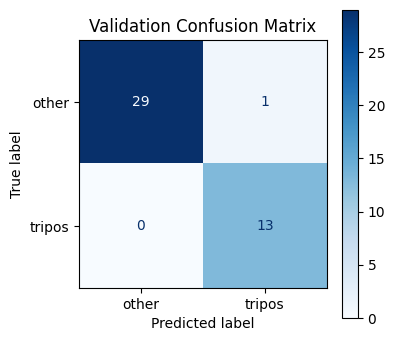

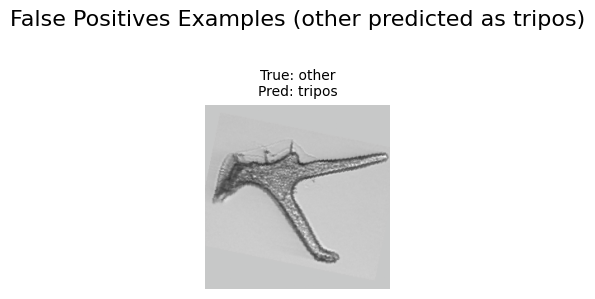

No false negatives examples (tripos predicted as other) examples found.


In [71]:
# To start training:
model = train_phytoplankton_model(model, criterion, optimizer, num_epochs=40)

# 7. Display confusion matrix on validation set
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_val_preds = []
all_val_labels = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_val_preds.extend(preds.cpu().numpy())
        all_val_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_val_labels, all_val_preds)

# Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Validation Confusion Matrix')
plt.show()

# Display actual false positive / false negative image examples
# cm=[[TN,FP],[FN,TP]] for binary classification
tn, fp, fn, tp = cm.ravel()

false_pos_indices = [i for i,(t,p) in enumerate(zip(all_val_labels, all_val_preds)) if t == train_dataset.class_to_idx['other'] and p == train_dataset.class_to_idx['tripos']]
false_neg_indices = [i for i,(t,p) in enumerate(zip(all_val_labels, all_val_preds)) if t == train_dataset.class_to_idx['tripos'] and p == train_dataset.class_to_idx['other']]

def denormalize(img_tensor):
    inv_transform = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )
    return torch.clamp(inv_transform(img_tensor), 0, 1)

def show_examples(indices, dataset, title, max_examples=8):
    if len(indices) == 0:
        print(f'No {title.lower()} examples found.')
        return

    n = min(len(indices), max_examples)
    ncols = min(4, n)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3*nrows))
    axes = axes.flatten() if n > 1 else [axes]

    for ax in axes[n:]:
        ax.axis('off')

    for i, idx in enumerate(indices[:n]):
        img_tensor, label = dataset[idx]
        img = denormalize(img_tensor)
        axes[i].imshow(img.permute(1, 2, 0).numpy())
        axes[i].axis('off')
        true_label = train_dataset.classes[all_val_labels[idx]]
        pred_label = train_dataset.classes[all_val_preds[idx]]
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10)

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

show_examples(false_pos_indices, val_dataset, 'False Positives Examples (other predicted as tripos)')
show_examples(false_neg_indices, val_dataset, 'False Negatives Examples (tripos predicted as other)')

In [72]:
torch.save(model.state_dict(), 'tripos_classifier_v17.pth')